# 3-bit repetition codes

This notebook demonstrates the repetition-code compiler passes. `rep3_bit` encodes each logical qubit as three physical qubits and decodes measurements with `qstack.decode @majority_vote`. `rep3_phase` is the phase-flip sibling: allocated logical zero is prepared as `|+++>`, measurements are taken in the phase basis, and results are decoded with `qstack.decode @phase_majority_vote`.

Because both passes are module-to-module transformations over the same qstack IR, composing them builds the 9-qubit Shor-style demonstration code.


## 1. A tiny logical program

We prepare $|1\rangle$ by applying `X` to $|0\rangle$ and measure it. In
the unprotected program one `X` gate is enough — but if any gate is
followed by a bit-flip, the measurement is wrong with probability 1.

In [1]:
%load_ext qstack.jupyter

In [2]:
%%qasm logical
QSTACKQASM 0.1;
include "qstack/cliffords.inc";

qreg q[1];
creg c[1];
x q[0];
measure q[0] -> c[0];

<ModuleOp 4490936736(operands=[], results=[], successors=[], properties={}, attributes={}, regions=[<Region 4490937408>], parent=None, _next_op=None, _prev_op=None)>

In [3]:
print(logical)
dataflow(logical).display()

builtin.module {
  qstack.kernel @main <[], [!qstack.bit]> allocates 1 {
  ^bb0(%0: !qstack.qubit):
    %1 = cliffords.x %0
    %2 = qstack.measure %1
    qstack.return %2 : !qstack.bit
  }
}


```mermaid
flowchart TB
  subgraph kernel_root["@main"]
    direction TB
    arg0(["%0 (fresh)"])
    op0["x"]
    op1{{"measure"}}
    return["return"]
    hostIn(("host"))
  end
  arg0 -- "%0" --> op0
  op0 -- "%1" --> op1
  op1 == "%2" ==> return
  hostIn -. "host" .-> return
```

## 2. Compile with the 3-bit repetition pass

`compile_rep3_bit` rewrites the module:

- every `!qstack.qubit` value becomes **three** physical qubits,
- every single-qubit Clifford (`H`, `X`, `Z`, `S`) is applied
  transversally on each of the three copies,
- every `qstack.measure` becomes three measurements followed by a
  `qstack.decode @majority_vote` outside the kernel boundary.

Compare the dataflow diagram to the logical version above.

In [4]:
from qstack.passes.rep3_bit import compile_rep3_bit, register_rep3_bit_callbacks

encoded = compile_rep3_bit(logical)
print(encoded)
dataflow(encoded).display()

builtin.module {
  qstack.kernel @main <[], [!qstack.bit]> allocates 3 {
  ^bb0(%0: !qstack.qubit, %1: !qstack.qubit, %2: !qstack.qubit):
    %3 = cliffords.x %0
    %4 = cliffords.x %1
    %5 = cliffords.x %2
    %6 = qstack.measure %3
    %7 = qstack.measure %4
    %8 = qstack.measure %5
    %9 = qstack.decode @__qstack_rep3_bit_decode(%6, %7, %8)
    qstack.return %9 : !qstack.bit
  }
  qstack.decoder @__qstack_rep3_bit_decode arity 3
}


```mermaid
flowchart TB
  subgraph kernel_root["@main"]
    direction TB
    arg0(["%0 (fresh)"])
    arg1(["%1 (fresh)"])
    arg2(["%2 (fresh)"])
    op0["x"]
    op1["x"]
    op2["x"]
    op3{{"measure"}}
    op4{{"measure"}}
    op5{{"measure"}}
    op6[["decode @__qstack_rep3_bit_decode"]]
    return["return"]
    hostIn(("host"))
  end
  arg0 -- "%0" --> op0
  arg1 -- "%1" --> op1
  arg2 -- "%2" --> op2
  op0 -- "%3" --> op3
  op1 -- "%4" --> op4
  op2 -- "%5" --> op5
  op3 == "%6" ==> op6
  op4 == "%7" ==> op6
  op5 == "%8" ==> op6
  op6 == "%9" ==> return
  hostIn -. "host" .-> op6
  op6 -. "host" .-> return
```

## 3. Run the encoded program

The encoded module still surfaces a single classical bit through `main`.
We register the `majority_vote` decoder on a `CallbackRegistry` and run
1000 shots — every shot should return `[1]`.

In [5]:
from qstack.runtime import CallbackRegistry, Machine

reg = CallbackRegistry()
register_rep3_bit_callbacks(reg)

machine = Machine(encoded, num_qubits=4, registry=reg)
results = machine.eval(shots=1000)
results

Results(1000 shots, histogram={(1,): 1000})

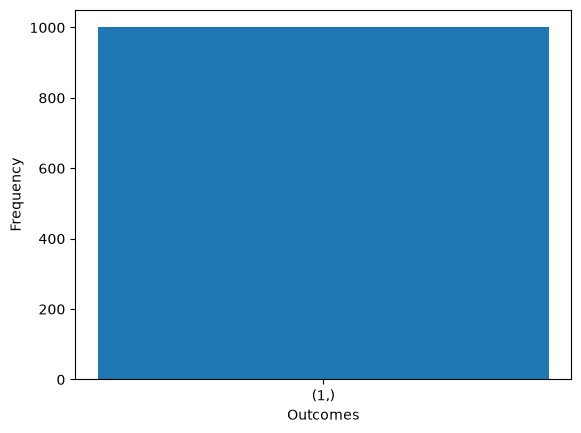

<Axes: xlabel='Outcomes', ylabel='Frequency'>

In [6]:
results.plot_histogram()

## 4. Compose bit and phase repetition into a Shor-style code

Applying the bit pass and then the phase pass widens each logical qubit to nine physical qubits. The original program and callback boundary do not change; the module simply gains another QEC layer and another decoder declaration.


In [7]:
from qstack.passes.rep3_phase import compile_rep3_phase, register_rep3_phase_callbacks

shor = compile_rep3_phase(encoded)
register_rep3_phase_callbacks(reg)
print(shor)


builtin.module {
  qstack.kernel @main <[], [!qstack.bit]> allocates 9 {
  ^bb0(%0: !qstack.qubit, %1: !qstack.qubit, %2: !qstack.qubit, %3: !qstack.qubit, %4: !qstack.qubit, %5: !qstack.qubit, %6: !qstack.qubit, %7: !qstack.qubit, %8: !qstack.qubit):
    %9 = cliffords.h %0
    %10 = cliffords.h %1
    %11 = cliffords.h %2
    %12 = cliffords.h %3
    %13 = cliffords.h %4
    %14 = cliffords.h %5
    %15 = cliffords.h %6
    %16 = cliffords.h %7
    %17 = cliffords.h %8
    %18 = cliffords.z %9
    %19 = cliffords.z %10
    %20 = cliffords.z %11
    %21 = cliffords.z %12
    %22 = cliffords.z %13
    %23 = cliffords.z %14
    %24 = cliffords.z %15
    %25 = cliffords.z %16
    %26 = cliffords.z %17
    %27 = cliffords.h %18
    %28 = qstack.measure %27
    %29 = cliffords.h %19
    %30 = qstack.measure %29
    %31 = cliffords.h %20
    %32 = qstack.measure %31
    %33 = qstack.decode @__qstack_rep3_phase_decode(%28, %30, %32)
    %34 = cliffords.h %21
    %35 = qstack.measure %34
    

The printed IR shows the 9-wire composition; a graph at this scale would be less readable:

- the kernel now allocates **9** physical qubits,
- each bit-code physical lane is expanded by the phase-code pass,
- `qstack.decode @phase_majority_vote` collapses each outer phase triple,
- the original `qstack.decode @majority_vote` remains as the inner bit-code decoder.

Running the composed program only requires adding the phase decoder to the same callback registry.


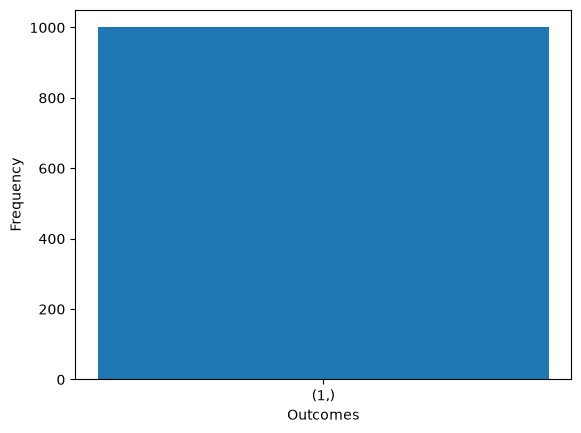

<Axes: xlabel='Outcomes', ylabel='Frequency'>

In [8]:
machine2 = Machine(shor, num_qubits=9, registry=reg)
results2 = machine2.eval(shots=1000)
results2.plot_histogram()


Two different repetition passes, one callback registry, same `Machine`: this is the Shor-code composition pattern. The compiler output remains regular qstack IR, so it can still feed later hardware-lowering passes.
